In [39]:
import numpy as np
import pandas as pd

import keras
import tensorflow as tf
import plotly.express as px

In [40]:
taxi_dataset = pd.read_csv('chicago_taxi_train.csv')
taxi_dataset.head()

,TRIP_START_TIMESTAMP,TRIP_END_TIMESTAMP,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_CENSUS_TRACT,DROPOFF_CENSUS_TRACT,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TIPS,TIP_RATE,TOLLS,EXTRAS,TRIP_TOTAL,PAYMENT_TYPE,COMPANY
0,05/17/2022 7:15:00 AM,05/17/2022 7:45:00 AM,7.25,2341,2.57,4.0,NaN,NaN,NaN,17.0,31.99,2.0,6.3,0.0,0.0,33.99,Mobile,Flash Cab
1,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1074,1.18,4.0,NaN,1.703108e+10,NaN,8.0,9.75,3.0,27.9,0.0,1.0,14.25,Credit Card,Flash Cab
2,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1173,1.29,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.25,0.0,0.0,0.0,0.0,10.25,Cash,Sun Taxi
3,05/17/2022 6:00:00 PM,05/17/2022 7:00:00 PM,18.00,3360,3.70,4.0,1.703132e+10,1.703124e+10,32.0,24.0,23.75,0.0,0.0,0.0,1.0,24.75,Cash,Choice Taxi Association
4,05/17/2022 5:00:00 PM,05/17/2022 5:30:00 PM,17.00,1044,1.15,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.00,0.0,0.0,0.0,0.0,10.00,Cash,Flash Cab


In [41]:
# Update the dataframe to use specific words
training_df = taxi_dataset.loc[:, ('TRIP_MILES', 'TRIP_SECONDS', 'FARE', 'COMPANY', 'PAYMENT_TYPE', 'TIP_RATE')]

print("Read Dataset completed successfully")
print("Totol number of rows: {0}\n\n".format(len(training_df.index)))
training_df.head(200)

Read Dataset completed successfully
Totol number of rows: 31694




,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
0,2.57,2341,31.99,Flash Cab,Mobile,6.3
1,1.18,1074,9.75,Flash Cab,Credit Card,27.9
2,1.29,1173,10.25,Sun Taxi,Cash,0.0
3,3.70,3360,23.75,Choice Taxi Association,Cash,0.0
4,1.15,1044,10.00,Flash Cab,Cash,0.0
...,...,...,...,...,...,...
195,1.13,821,9.00,Blue Ribbon Taxi Association,Mobile,22.9
196,0.57,414,6.00,Flash Cab,Cash,0.0
197,1.22,886,9.00,City Service,Cash,0.0
198,1.68,1219,9.00,Sun Taxi,Mobile,23.0


In [42]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31694 entries, 0 to 31693
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TRIP_MILES    31694 non-null  float64
 1   TRIP_SECONDS  31694 non-null  int64  
 2   FARE          31694 non-null  float64
 3   COMPANY       31694 non-null  object 
 4   PAYMENT_TYPE  31694 non-null  object 
 5   TIP_RATE      31694 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 1.5+ MB


In [43]:
training_df.describe().T

,count,mean,std,min,25%,50%,75%,max
TRIP_MILES,31694.0,8.289463,7.265672,0.50,1.72,5.92,14.50,68.12
TRIP_SECONDS,31694.0,1319.796397,928.932873,60.00,548.00,1081.00,1888.00,7140.00
FARE,31694.0,23.905210,16.970022,3.25,9.00,18.75,38.75,159.25
TIP_RATE,31694.0,12.965785,15.517765,0.00,0.00,12.20,20.80,648.60


In [44]:
max_fare = training_df['FARE'].max()
print("The maximum fare is:", max_fare)

mean_distance = training_df['TRIP_MILES'].mean()
print("The mean distance of trip is:", mean_distance)

num_unique_companies = training_df['COMPANY'].nunique()
print("the total cap companies are:", num_unique_companies)

most_frequent_type = training_df['PAYMENT_TYPE'].value_counts().idxmax()
print("The most frequent payment method is:", most_frequent_type)

missing_values = training_df.isnull().sum().sum()
print("The missing value are:", missing_values)

The maximum fare is: 159.25
The mean distance of trip is: 8.289462674323214
the total cap companies are: 31
The most frequent payment method is: Credit Card
The missing value are: 0


In [45]:
#@title Code - View correlation matrix
training_df.corr(numeric_only = True)

,TRIP_MILES,TRIP_SECONDS,FARE,TIP_RATE
TRIP_MILES,1.000000,0.800855,0.975344,-0.049594
TRIP_SECONDS,0.800855,1.000000,0.830292,-0.084294
FARE,0.975344,0.830292,1.000000,-0.070979
TIP_RATE,-0.049594,-0.084294,-0.070979,1.000000


In [46]:
px.scatter_matrix(training_df, dimensions=['FARE', 'TRIP_MILES', 'TRIP_SECONDS'])

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'dimensions': [{'axis': {'matches': True},
                              'label': 'FARE',
                              'values': {'bdata': ('PQrXo3D9P0AAAAAAAIAjQAAAAAAAgC' ... 'AAwD5AAAAAAADgREAAAAAAAKBHQA=='),
                                         'dtype': 'f8'}},
                             {'axis': {'matches': True},
                              'label': 'TRIP_MILES',
                              'values': {'bdata': ('j8L1KFyPBEDhehSuR+HyP6RwPQrXo/' ... '6FayhAzczMzMxMQkCamZmZmVlCQA=='),
                                         'dtype': 'f8'}},
                             {'axis': {'matches': True},
                              'label': 'TRIP_SECONDS',
                              'values': {'bdata': ('JQkyBJUEIA0UBOMEFQdBBxMDdwVeDx' ... 'PcBUgD3QKHCxAB4wLMBq8C+Af4Bw=='),
                                         'dtype': 'i2'}}],
              'hovertemplate': '%{xaxis.title.text}=%{x}<br>%{yaxis.title.text}=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'symbol': 'circle'},
              'name': '',
              'showlegend': False,
              'type': 'splom'}],
    'layout': {'dragmode': 'select', 'legend': {'tracegroupgap': 0}, 'margin': {'t': 60}, 'template': '...'}
})

In [47]:
# Set the Hyperparameter
learning_rate = 0.001
number_epochs = 20
batch_size = 50
input_features = ['TRIP_MILES']
target = 'FARE'


In [49]:
# Creating the Model
model_1 = keras.Sequential([
    keras.layers.Input(shape=(len(input_features),)),
    keras.layers.Dense(1)
])

model_1.compile(
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate),
    loss='mse',
    metrics = [keras.metrics.RootMeanSquaredError(name='mse')]
)

model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [50]:
# preparing the training data
X_train = training_df[input_features].values
y_train = training_df[target].values

In [52]:
# train the model
history = model_1.fit(
    X_train,
    y_train,
    epochs=number_epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 309.5099 - mse: 17.5929
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 139.2615 - mse: 11.8009
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 58.1095 - mse: 7.6230
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 27.5424 - mse: 5.2481
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 19.4288 - mse: 4.4078
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 17.8855 - mse: 4.2291
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 17.3162 - mse: 4.1613
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 16.7713 - mse: 4.0953
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 16.2025 - mse: 4.0252
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 15.6555 - mse: 3.9567
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 15.1666 - mse: 3.8944
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 14.7672 - mse: 3.8428
Epoch 13/

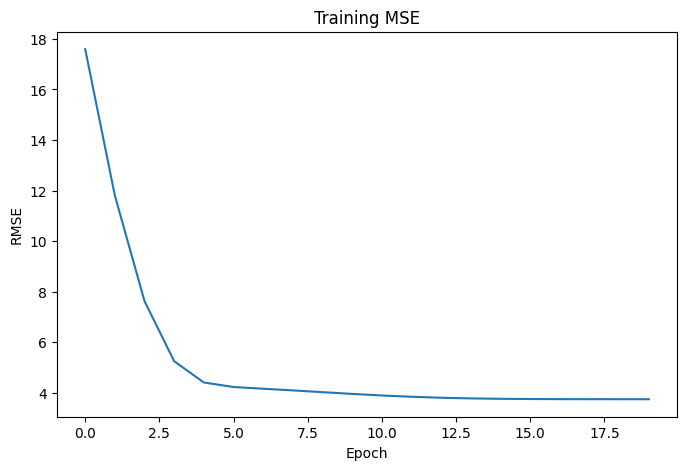

dict_keys(['loss', 'mse'])


In [59]:
# Plot the RMSE
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history.history['mse'])

plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Training MSE')

plt.show()
print(history.history.keys())

991/991 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


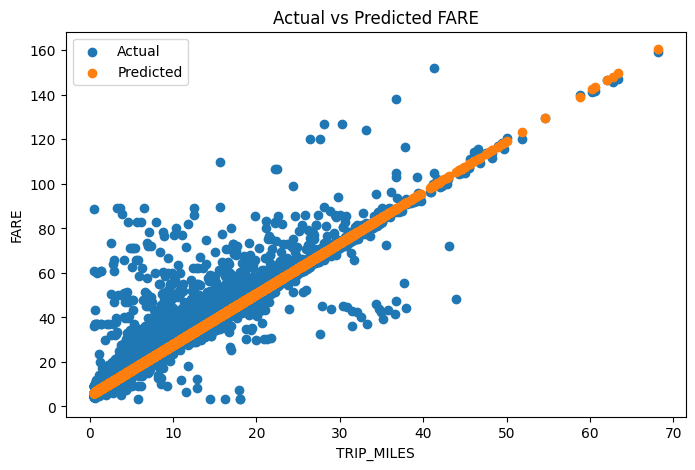

In [60]:
predictions = model_1.predict(X_train).flatten()

plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, label='Actual')
plt.scatter(X_train, predictions, label='Predicted')

plt.xlabel('TRIP_MILES')
plt.ylabel('FARE')
plt.title('Actual vs Predicted FARE')
plt.legend()

plt.show()